# Relax Data Science Challenge

In this project, we were asked to build a model to predict active users from login data. Active users were defined as anyone who has logged in three times in any 7 day period in the dataset.  

My approach will be to clean and check both datasets, then use the login data to define the status of active or inactive.  I'll then merge this target with the user data.


In [1]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from xgboost import XGBClassifier

In [3]:
users = pd.read_csv('C:/Users/svobo/OneDrive/Documents/GitHub/Springboard/relax_challenge/takehome_users.csv', encoding='latin-1')
logins = pd.read_csv('C:/Users/svobo/OneDrive/Documents/GitHub/Springboard/relax_challenge/takehome_user_engagement.csv', encoding='latin-1')

## Data Cleaning

In [4]:
users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [5]:
users.isna().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time    3177
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
invited_by_user_id            5583
dtype: int64

For last_session, this is numeric so we will use the median value.  For the invited column, the most important information is the the user was invited, no the user id, so we will make a new column that is categorical.

In [6]:
users['were_invited'] = users['invited_by_user_id'].isna().map({False: 1, True:0})
users = users.drop(columns='invited_by_user_id')
users['last_session_creation_time'] = users['last_session_creation_time'].fillna(users['last_session_creation_time'].median())
users.isna().sum()


object_id                     0
creation_time                 0
name                          0
email                         0
creation_source               0
last_session_creation_time    0
opted_in_to_mailing_list      0
enabled_for_marketing_drip    0
org_id                        0
were_invited                  0
dtype: int64

In [7]:
users.dtypes

object_id                       int64
creation_time                     str
name                              str
email                             str
creation_source                   str
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
were_invited                    int64
dtype: object

In [8]:
users['creation_time'] = pd.to_datetime(users['creation_time'])
users['opted_in_to_mailing_list'] = users['opted_in_to_mailing_list'].astype('category')
users['enabled_for_marketing_drip'] = users['enabled_for_marketing_drip'].astype('category')
users['were_invited'] = users['were_invited'].astype('category')
users.dtypes

object_id                              int64
creation_time                 datetime64[us]
name                                     str
email                                    str
creation_source                          str
last_session_creation_time           float64
opted_in_to_mailing_list            category
enabled_for_marketing_drip          category
org_id                                 int64
were_invited                        category
dtype: object

In [9]:
logins.isna().sum()

time_stamp    0
user_id       0
visited       0
dtype: int64

In [10]:
logins.dtypes

time_stamp      str
user_id       int64
visited       int64
dtype: object

In [11]:
logins['time_stamp'] = pd.to_datetime(logins['time_stamp'])
logins.dtypes

time_stamp    datetime64[us]
user_id                int64
visited                int64
dtype: object

In [12]:
logins.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


## Target Definition

In [13]:
logins = logins.sort_values(['user_id', 'time_stamp'])

logins['rolling_7d'] = (
    logins.groupby('user_id')
      .rolling('7D', on='time_stamp')['visited']
      .count()
      .reset_index(drop=True)
)

In [14]:
logins.head(20)

,time_stamp,user_id,visited,rolling_7d
0,2014-04-22 03:53:30,1,1,1.0
1,2013-11-15 03:45:04,2,1,1.0
2,2013-11-29 03:45:04,2,1,1.0
3,2013-12-09 03:45:04,2,1,1.0
4,2013-12-25 03:45:04,2,1,1.0
5,2013-12-31 03:45:04,2,1,2.0
6,2014-01-08 03:45:04,2,1,1.0
7,2014-02-03 03:45:04,2,1,1.0
8,2014-02-08 03:45:04,2,1,2.0
9,2014-02-09 03:45:04,2,1,3.0


In [15]:
logins_max = logins.groupby('user_id')['rolling_7d'].max()
logins_max_df = logins_max.to_frame(name='rolling_max').reset_index()
logins_max_df.head(10)

,user_id,rolling_max
0,1,1.0
1,2,3.0
2,3,1.0
3,4,1.0
4,5,1.0
5,6,1.0
6,7,1.0
7,10,7.0
8,11,1.0
9,13,1.0


In [16]:
logins_max_df['status'] = (logins_max_df['rolling_max'] >=3).map({True: 1, False: 0})
logins_max_df['object_id'] = logins_max_df['user_id']
logins_max_df = logins_max_df.drop(columns='user_id')
logins_max_df.head()

,rolling_max,status,object_id
0,1.0,0,1
1,3.0,1,2
2,1.0,0,3
3,1.0,0,4
4,1.0,0,5


In [17]:
users = users.merge(logins_max_df, how='left', on='object_id')
users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,were_invited,rolling_max,status
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,1,1.0,0.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,1,3.0,1.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1,1.0,0.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,1,1.0,0.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,1,1.0,0.0


Now we have the target in the user dataset.  Last step is fill in the NAs from as users who were not in the login data.

In [18]:
users.isna().sum()

object_id                        0
creation_time                    0
name                             0
email                            0
creation_source                  0
last_session_creation_time       0
opted_in_to_mailing_list         0
enabled_for_marketing_drip       0
org_id                           0
were_invited                     0
rolling_max                   3177
status                        3177
dtype: int64

In [19]:
users['status'] = users['status'].fillna(0.0)
users['rolling_max'] = users['rolling_max'].fillna(0.0)
users.isna().sum()

object_id                     0
creation_time                 0
name                          0
email                         0
creation_source               0
last_session_creation_time    0
opted_in_to_mailing_list      0
enabled_for_marketing_drip    0
org_id                        0
were_invited                  0
rolling_max                   0
status                        0
dtype: int64

## Modelling

I will followed a standard classification machine learning pipeline:

1. Train/test split
2. Standardize numeric columns and One Hot Encode categorical columns
4. Screen Random Forest and XGBoost Classifiers with Cross Validation
5. Hyperparameter Tune Top Classifier 
6. Examine Feature Importance

For our metric, we will use the ROC-AUC as this does a good job generalizing for false positives and false negatives.  In this buisiness problem, there is not a clear difference in the importance of detecting inactive vs active users, since the goal of the project is understanding why users are inactive. However, this data is moderatly imbalanced, so I'll use the confusion matrix to tell us where the mistakes are happening and give further insight into optimizations.


In [20]:
#make new df for modelling before we start changing columns too much. 
users_model = users.copy()
#Extact meaningful features from date_time columns into categorical columns
users_model['creation_year'] = users_model['creation_time'].dt.year
users_model['creation_month'] = users_model['creation_time'].dt.month
users_model['creation_day'] = users_model['creation_time'].dt.day
#Remove the last trip date because that is essentially the target. Also remove name and email since this data isn't useful for modelling and will cause issues with One Hot Enconding
users_model = users_model.drop(columns=['creation_time', 'rolling_max', 'name', 'email'])
users_model.head()

,object_id,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,were_invited,status,creation_year,creation_month,creation_day
0,1,GUEST_INVITE,1.398139e+09,1,0,11,1,0.0,2014,4,22
1,2,ORG_INVITE,1.396238e+09,0,0,1,1,1.0,2013,11,15
2,3,ORG_INVITE,1.363735e+09,0,0,94,1,0.0,2013,3,19
3,4,GUEST_INVITE,1.369210e+09,0,0,1,1,0.0,2013,5,21
4,5,GUEST_INVITE,1.358850e+09,0,0,193,1,0.0,2013,1,17


In [21]:
X = users_model.drop(columns='status')
y = users_model['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=42)

In [22]:
num_cols = ['object_id', 'last_session_creation_time', 'org_id', 'creation_year', 'creation_month', 'creation_day']
cat_cols = ['creation_source', 'opted_in_to_mailing_list', 'enabled_for_marketing_drip', 'were_invited']

processor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

model_RF = Pipeline([('prep', processor), ('model', RandomForestClassifier())])

scores = cross_validate(model_RF, X_train, y_train, cv=5, scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'])
print({k: v.mean() for k, v in scores.items() if 'test' in k})

{'test_accuracy': np.float64(0.961111111111111), 'test_roc_auc': np.float64(0.9665832169594107), 'test_precision': np.float64(0.9556790400411141), 'test_recall': np.float64(0.7414225941422593), 'test_f1': np.float64(0.8343893951327308)}


In [23]:
model_RF.fit(X_train, y_train)
y_pred_RF = model_RF.predict(X_test)
y_prob_RF = model_RF.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob_RF)

0.9739342645243148

In [24]:
confusion_matrix(y_test, y_pred_RF)

array([[2578,   15],
       [  90,  317]])

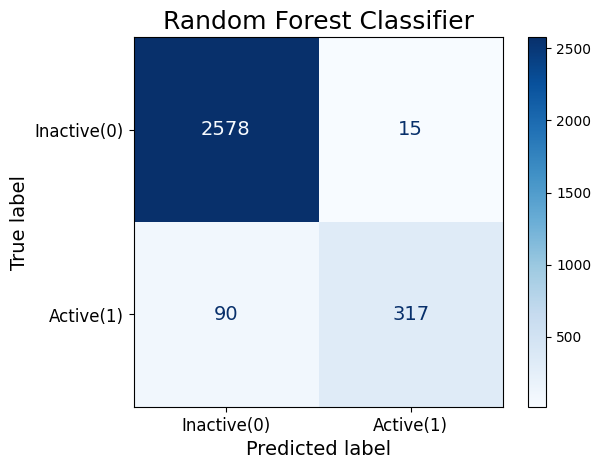

In [25]:
cm = confusion_matrix(y_test, y_pred_RF)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive(0)', 'Active(1)'])

ax = disp.plot(cmap=plt.cm.Blues).ax_

# Change the numbers inside the squares
for text in ax.texts:
    text.set_fontsize(14)

ax.set_title('Random Forest Classifier', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)

ax.tick_params(axis='both', labelsize=12)

plt.show()

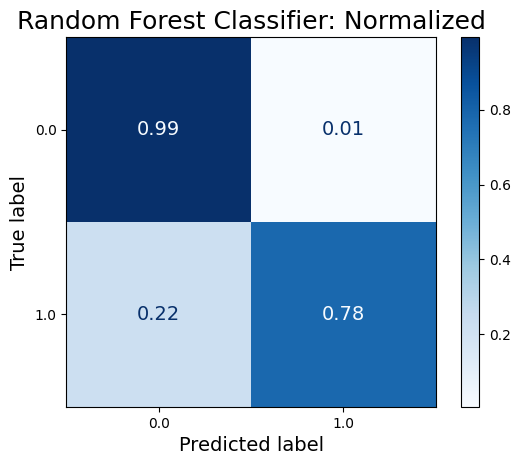

In [32]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_RF,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)

ax = disp.ax_
for text in ax.texts:
    text.set_fontsize(14)
ax.set_title('Random Forest Classifier: Normalized', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)
plt.show()

In [26]:
processor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

model_XG = Pipeline([('prep', processor), ('model', XGBClassifier())])
scores = cross_validate(model_XG, X_train, y_train, cv=5, scoring=['accuracy', 'roc_auc', 'precision', 'recall', 'f1'])
print({k: v.mean() for k, v in scores.items() if 'test' in k})

{'test_accuracy': np.float64(0.9692222222222222), 'test_roc_auc': np.float64(0.9819925538558858), 'test_precision': np.float64(0.9144625811199589), 'test_recall': np.float64(0.8476987447698745), 'test_f1': np.float64(0.8796589211052985)}


In [27]:
model_XG.fit(X_train, y_train)
y_pred_XG = model_XG.predict(X_test)
y_prob_XG = model_XG.predict_proba(X_test)[:,1]
roc_auc_score(y_test, y_prob_XG)

0.9881698126973869

In [28]:
confusion_matrix(y_test, y_pred_XG)

array([[2568,   25],
       [  51,  356]])

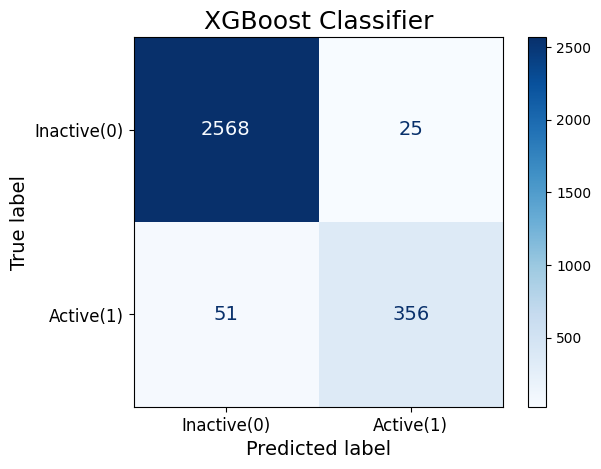

In [33]:
cm = confusion_matrix(y_test, y_pred_XG)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive(0)', 'Active(1)'])

ax = disp.plot(cmap=plt.cm.Blues).ax_

# Change the numbers inside the squares
for text in ax.texts:
    text.set_fontsize(14)

ax.set_title('XGBoost Classifier', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)

ax.tick_params(axis='both', labelsize=12)

plt.show()

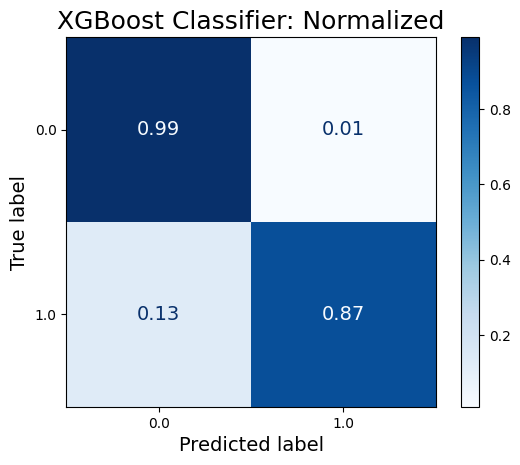

In [35]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_XG,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)

ax = disp.ax_
for text in ax.texts:
    text.set_fontsize(14)
ax.set_title('XGBoost Classifier: Normalized', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)
plt.show()

XGBoost Classifier performed the best in all metrics, with the greatest difference in metrics that account for false negatives like F1 and Recall.  Most importantly, XGBoost had a more balanced confusion matrix, whcih is especially important for imbalanced data.  The XGBoost Classifier will move forward into hyperparameter tuning.

## Hyperparameter Tuning

In [38]:
param_grid = {
    'model__booster': ['gbtree'],
    'model__scale_pos_weight': [1, 3, 5, 7],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'model__reg_lambda': [0.5, 1, 2, 5],
    'model__gamma': [0, 0.1, 0.5],
    'model__max_depth': [3, 5, 7, 10],
    'model__n_estimators': [100, 200, 300]
}
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])
model = Pipeline([('prep', preprocessor), ('model', XGBClassifier())])

XGB_cv = RandomizedSearchCV(estimator=model, param_distributions=param_grid, cv=5, scoring='f1')

XGB_cv.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__booster': ['gbtree'], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be 

In [39]:
results_XGB = pd.DataFrame(XGB_cv.cv_results_)
top_10_XGB = results_XGB.sort_values(by='mean_test_score', ascending=False).head(10)
params_expanded = pd.json_normalize(top_10_XGB['params'])
top_10_XGB_full = pd.concat([top_10_XGB[["rank_test_score", "mean_test_score"]].reset_index(drop=True), params_expanded.reset_index(drop=True)], axis=1)
top_10_XGB_full['Mean F1'] = top_10_XGB_full['mean_test_score']
top_10_XGB_full = top_10_XGB_full.drop('mean_test_score', axis=1)
top_10_XGB_full

,rank_test_score,model__scale_pos_weight,model__reg_lambda,model__n_estimators,model__max_depth,model__learning_rate,model__gamma,model__booster,Mean F1
0,1,5,0.5,200,3,0.20,0.5,gbtree,0.889601
1,2,5,2.0,300,5,0.05,0.1,gbtree,0.887829
2,3,3,1.0,200,5,0.20,0.0,gbtree,0.886401
3,4,5,0.5,100,7,0.05,0.5,gbtree,0.886300
4,5,5,2.0,100,5,0.10,0.0,gbtree,0.884500
5,6,1,5.0,300,5,0.30,0.0,gbtree,0.883220
6,7,3,1.0,200,10,0.10,0.5,gbtree,0.883150
7,8,3,0.5,300,7,0.20,0.5,gbtree,0.881660
8,9,7,5.0,100,10,0.10,0.0,gbtree,0.879976
9,10,3,5.0,100,3,0.05,0.1,gbtree,0.844234


In [51]:
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols), ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])
model = XGBClassifier(booster = 'gbtree', n_estimators = 300, scale_pos_weight = 5, reg_lambda=2, gamma= 0.1, learning_rate=0.05, max_depth=5)
final_model_XG = Pipeline([('prep', preprocessor), ('model', model)])
final_model_XG = final_model_XG.fit(X_train, y_train)
y_pred_XGB = final_model_XG.predict(X_test)
y_prob_XGB = final_model_XG.predict_proba(X_test)[:,1]

Note: I went with the settings for the second rank test score.  I tried both and found that the second set of setting were slightly more balanced in terms of false positives and false negatives.  Both settings moved the results from fewer false negatives and more false positives (total counts) than the default model, which is approrpiate for this imblanced data with ~5x more true negatives than true positives.

In [52]:
roc_auc_score(y_test, y_prob_XGB)

0.9885905258061063

In [53]:
confusion_matrix(y_test, y_pred_XGB)

array([[2546,   47],
       [  34,  373]])

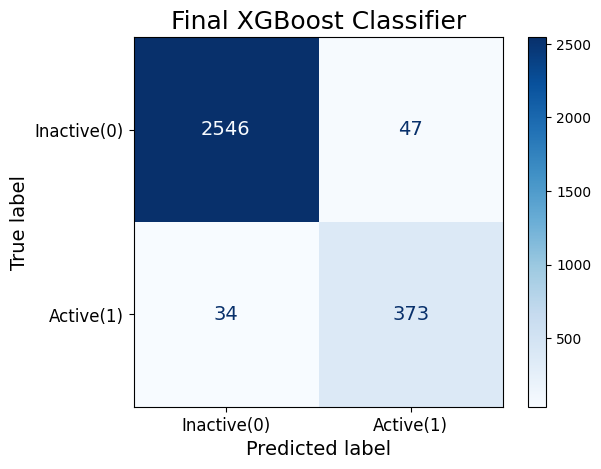

In [54]:
cm = confusion_matrix(y_test, y_pred_XGB)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Inactive(0)', 'Active(1)'])

ax = disp.plot(cmap=plt.cm.Blues).ax_

# Change the numbers inside the squares
for text in ax.texts:
    text.set_fontsize(14)

ax.set_title('Final XGBoost Classifier', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)

ax.tick_params(axis='both', labelsize=12)

plt.show()

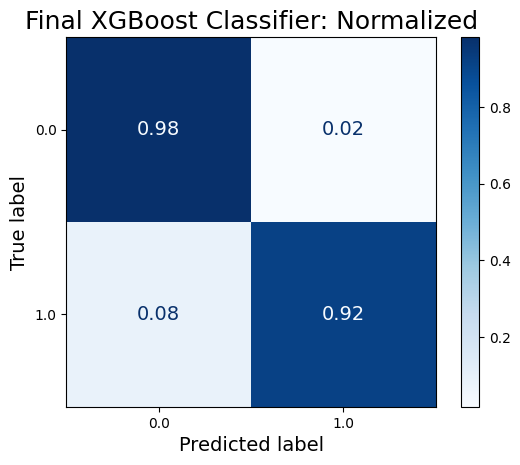

In [55]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_XGB,
    normalize='true',
    cmap='Blues',
    values_format='.2f'
)

ax = disp.ax_
for text in ax.texts:
    text.set_fontsize(14)
ax.set_title('Final XGBoost Classifier: Normalized', fontsize=18)
ax.set_xlabel('Predicted label', fontsize=14)
ax.set_ylabel('True label', fontsize=14)
plt.show()

## Feature Importance

We have built a model that can accurately predict whether a user will be active.  This model could be passed to the client to help them find at risk users as it current stands.  However, an even more useful result of this project would be insight into how those predictions were made.  To do this, we will look at the feature importance as determined by the XGBoost model.

In [56]:
feature_names = X_test.columns
perm_XG = permutation_importance(final_model_XG, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2)

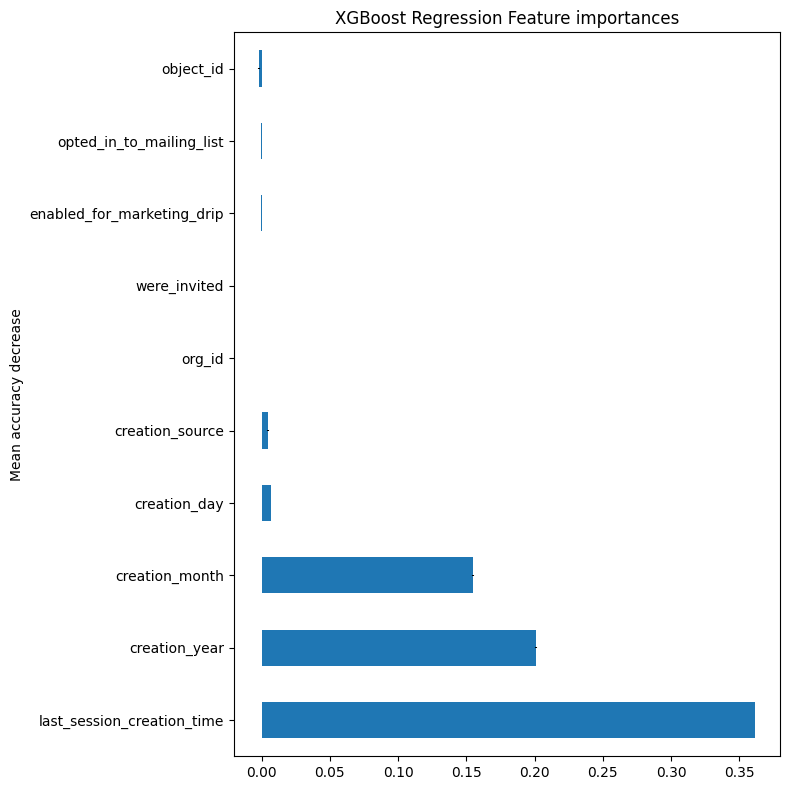

In [57]:
#Transform feature importance data into series for plotting
importances_mean = pd.Series(perm_XG.importances_mean, index=feature_names).sort_values(ascending=False)
importances_std = pd.Series(perm_XG.importances_std, index=feature_names).loc[importances_mean.index]

#Plot feature importances
fig, ax = plt.subplots(figsize=(8,8))
importances_mean.plot.barh(yerr=importances_std, ax=ax)
ax.set_title("XGBoost Regression Feature importances")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

From here we can see that last session creation time, creation year and creation month are important in determining a clients predicted status, but we don't know what about those catergories makes them informative.  To do this, we can look at Shap values.

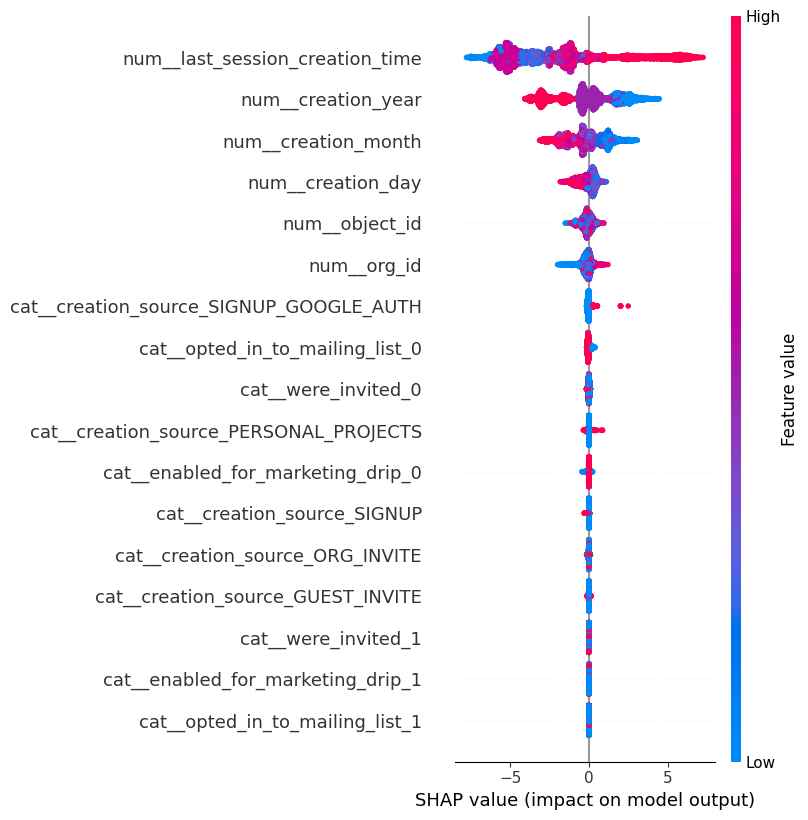

In [58]:
X_train_transformed = final_model_XG.named_steps['prep'].transform(X_train)

feature_names = final_model_XG.named_steps['prep'].get_feature_names_out()
X_train_transformed_df = pd.DataFrame(
    X_train_transformed.toarray() if hasattr(X_train_transformed, "toarray") else X_train_transformed,
    columns=feature_names
)
xgb_model = final_model_XG.named_steps['model']
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_transformed)
shap.summary_plot(shap_values, X_train_transformed_df, feature_names=feature_names)

A positive SHAP value pushes a prediction towards class 1 (Active) and a negative SHAP value pushes a prediction towards class 0 (Inactive). Red indicates high values, and blue indicates low values, and each dot represents a prediction. So blue dots on the postive (right) side of the x-axis mean that low values in that catergory inform class 1 predictions, while red dots on the right side of the axis mean that high values inform class 1 predictions.  This can be used to gain useful recommendations for the client. Here are few examples:

1. High numbers in 'last_session_creation_time' indicate uses that are more likely to be active.
2. For creation year, low numbers are associated with active users.  These must be users that have been with the company for a long time and are stable customers.  Also, they have more time to achieve an active status, which is three logins in 7 days.
3. For creation month and day, low numbers are also associated with active users.  The cause here is less clear, but it could be the same trend as seen for year on a smaller scale. 
 
For next steps, I would recommend doing a deeper dive into the login data and doing more feature creation to find out when the users are the most active.  This could include looking at weekday vs weekend logins, night vs daytime, or regular vs sporadic users.  While this level of analysis was outside the scope of this investigation, it would allow for a more nuanced model.  
